In [ ]:
!pip install rlcard[torch]

In [ ]:
import rlcard
from rlcard.agents import DQNAgent
from rlcard.agents import RandomAgent

In [ ]:
env = rlcard.make("custom")
print("Number of actions:", env.num_actions)
print("Number of players:", env.num_players)
print("Shape of state:", env.state_shape)
print("Shape of action:", env.action_shape)

Number of actions: 473
Number of players: 2
Shape of state: [[6, 7, 4], [6, 7, 4]]
Shape of action: [None, None]


In [ ]:
agent = DQNAgent(
    num_actions=env.num_actions,
    state_shape=env.state_shape[0],
    mlp_layers=[512, 512],
    learning_rate = 0.00005,
)
agents = [agent]
for _ in range(1, env.num_players):
        agents.append(RandomAgent(num_actions=env.num_actions))

In [ ]:
env.set_agents(agents)

In [ ]:
from rlcard.utils import (
    tournament,
    reorganize,
    Logger,
    plot_curve,
)

In [ ]:
with Logger("experiments/custom_dqn_result/") as logger:
    for episode in range(1000):

        # Generate data from the environment
        trajectories, payoffs = env.run(is_training=True)

        # Reorganaize the data to be state, action, reward, next_state, done
        trajectories = reorganize(trajectories, payoffs)

        # Feed transitions into agent memory, and train the agent
        for ts in trajectories[0]:
            agent.feed(ts)

        # Evaluate the performance.
        if episode % 50 == 0:
            logger.log_performance(
                env.timestep,
                tournament(
                    env,
                    1000,
                )[0]
            )

    # Get the paths
    csv_path, fig_path = logger.csv_path, logger.fig_path

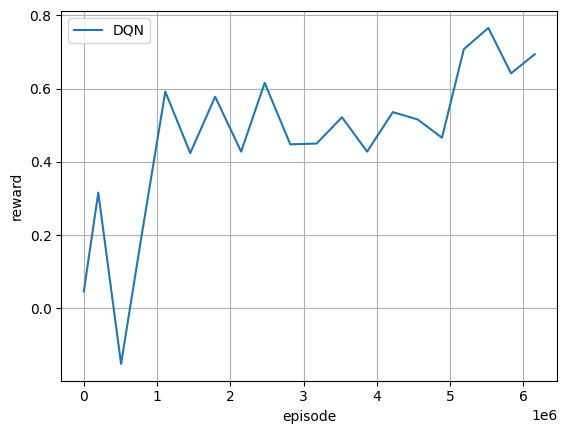

In [ ]:
plot_curve(csv_path, fig_path, "DQN")